In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, accuracy_score
import shap
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') # 시각화 스타일 설정

In [2]:
def build_advanced_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    # 결측치 처리 및 정렬
    df = df.sort_values('date').reset_index(drop=True).fillna(method='ffill').fillna(method='bfill')

    # 감성 에너지 및 모멘텀
    df['sent_energy'] = df['sent_strength_w'] * df['sent_norm_w']
    df['sent_norm_ma5'] = df['sent_norm_w'].rolling(5).mean()
    df['neg_z_inv'] = -df['neg_z']

    # 멀티 Lag 생성 (1일 전 정보)
    for i in range(1, 8):
        df[f'sub_index{i}_lag1'] = df[f'sub_index{i}'].shift(1)

    # 타겟 생성 (1일 수익률)
    df['target'] = df['log_return_t+1']
    df['target_cls'] = (df['target'] > 0).astype(int)

    return df.dropna().reset_index(drop=True)

def create_logical_kfgi(df):
    core_feats = [f'sub_index{i}' for i in range(1, 8)] + ['sent_norm_w', 'sent_energy', 'neg_z_inv']
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[core_feats])

    # Ridge를 활용한 가중치 산출
    ridge = RidgeCV().fit(X_scaled, df['target'])
    weights = np.abs(ridge.coef_) / np.sum(np.abs(ridge.coef_))

    # 0~100 스케일링 (KFGI)
    raw_fgi = X_scaled @ weights
    p1, p99 = np.percentile(raw_fgi, [1, 99])
    df['KFGI'] = 100 * (np.clip(raw_fgi, p1, p99) - p1) / (p99 - p1)
    return df, core_feats

In [4]:
# 경로 설정 (사용자 환경에 맞게 수정 필요)
data_path = '/content/drive/MyDrive/시계열 금융/KFG_final_2.csv'
df_raw = pd.read_csv(data_path)

df_eng = build_advanced_features(df_raw)
df_final, core_feats = create_logical_kfgi(df_eng)
df = df_final.copy()

# 타겟 및 피처 자동 식별
target_col = 'log_return_t+1' if 'log_return_t+1' in df.columns else 'actual_1d'
exclude_cols = ['date', 'kospi_close', 'log_return', 'log_return_t+1', 'actual_1d',
                'target_reg', 'target_3d', 'target_5d', 'KFGI', 'target','target_cls']
features = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

print(f"✅ 사용 타겟: {target_col}")
print(f"✅ 사용 피처 개수: {len(features)}")

✅ 사용 타겟: log_return_t+1
✅ 사용 피처 개수: 23


In [5]:
def run_final_strategy(df, features, target):
    tscv = TimeSeriesSplit(n_splits=5)
    X = df[features].fillna(0)
    y = df[target]

    results = []
    val_errors = []

    print("🔄 모델 학습 및 시계열 검증 진행 중...")
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Ridge + LGBM 앙상블
        model_r = Ridge(alpha=1.0).fit(X_train, y_train)
        model_l = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, num_leaves=63, verbosity=-1)
        model_l.fit(X_train, y_train)

        # 앙상블 예측 (LGBM 80% 비중)
        pred = (model_r.predict(X_test) * 0.2) + (model_l.predict(X_test) * 0.8)
        val_errors.append(np.sqrt(np.mean((y_test - pred)**2)))

        tmp = pd.DataFrame({
            'date': pd.to_datetime(df.iloc[test_idx]['date']),
            'actual': y_test,
            'pred': pred,
            'kfgi': df.iloc[test_idx]['KFGI'] if 'KFGI' in df.columns else 50
        })
        results.append(tmp)

    return pd.concat(results), val_errors

res_df, errors = run_final_strategy(df, features, target_col)

🔄 모델 학습 및 시계열 검증 진행 중...


In [6]:
bulldozer_res = res_df.copy()

# 하위 5% 예측치일 때만 회피, 그 외 공격적 매수
threshold = bulldozer_res['pred'].quantile(0.05)
bulldozer_res['signal'] = np.where(bulldozer_res['pred'] > threshold, 1, 0)

def calculate_bulldozer_weight(row):
    if row['kfgi'] < 45: return 2.5    # 과공포 시 강력 레버리지
    elif row['kfgi'] > 85: return 1.0  # 과열 시 비중 축소
    else: return 1.2                   # 보통 구간

bulldozer_res['bull_weight'] = bulldozer_res.apply(calculate_bulldozer_weight, axis=1)
bulldozer_res['bull_ret'] = bulldozer_res['signal'] * bulldozer_res['bull_weight'] * bulldozer_res['actual']

# 결과 출력
print("🚜 '불도저' 전략 성과")
# (성능 계산 로직 생략 - 아래 통합 리포트 함수 활용 권장)

🚜 '불도저' 전략 성과


In [7]:
FEES = 0.00015  # 편도 수수료 0.015%
LEVERAGE = 1.8

final_strategy_df = res_df.copy()
final_strategy_df['date'] = pd.to_datetime(final_strategy_df['date'])

# 추세 지표(MA5) 결합
df_kospi_close = df_raw[['date', 'kospi_close']].copy()
df_kospi_close['date'] = pd.to_datetime(df_kospi_close['date'])
final_strategy_df = pd.merge(final_strategy_df, df_kospi_close, on='date', how='left')

final_strategy_df['ma5'] = final_strategy_df['kospi_close'].rolling(5).mean()
final_strategy_df['market_trend'] = np.where(final_strategy_df['kospi_close'] > final_strategy_df['ma5'], 1, 0)
final_strategy_df.dropna(subset=['ma5'], inplace=True)

def get_final_weight(row):
    if row['market_trend'] == 1: # 상승 추세
        return LEVERAGE if row['pred'] > 0 else 1.0
    else: # 하락 추세
        return 0.3 if row['pred'] > 0.002 else 0.0

final_strategy_df['weight'] = final_strategy_df.apply(get_final_weight, axis=1)
final_strategy_df['turnover'] = final_strategy_df['weight'].diff().abs().fillna(LEVERAGE)
final_strategy_df['transaction_cost'] = final_strategy_df['turnover'] * FEES
final_strategy_df['strat_ret_net'] = (final_strategy_df['weight'] * final_strategy_df['actual']) - final_strategy_df['transaction_cost']

[Buy & Hold (Market)]
   - 연수익률: 19.38% | 샤프지수: 1.016 | MDD: -20.67%
[Bulldozer Strategy]
   - 연수익률: 27.26% | 샤프지수: 0.836 | MDD: -26.80%
[Hybrid Strategy (Net)]
   - 연수익률: 20.15% | 샤프지수: 1.078 | MDD: -10.49%


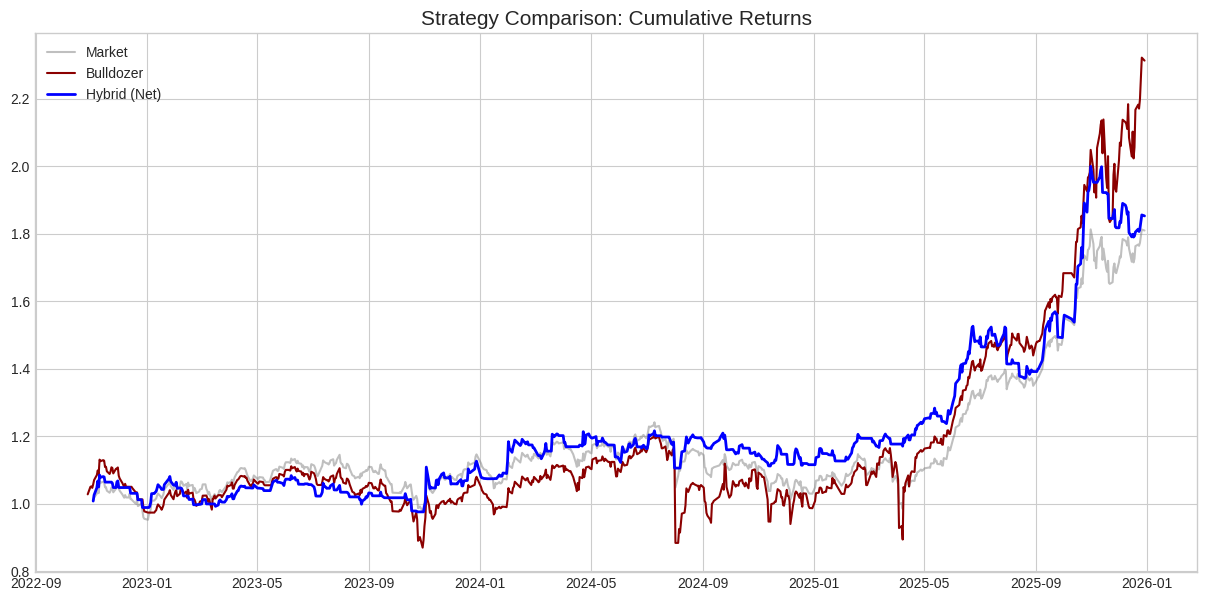

In [8]:
def print_performance(df, col_name, label):
    ann_ret = df[col_name].mean() * 252
    ann_vol = df[col_name].std() * np.sqrt(252)
    sharpe = ann_ret / (ann_vol + 1e-9)
    cum_ret = np.exp(df[col_name].cumsum())
    mdd = (cum_ret / cum_ret.cummax() - 1).min()

    print(f"[{label}]")
    print(f"   - 연수익률: {ann_ret*100:.2f}% | 샤프지수: {sharpe:.3f} | MDD: {mdd*100:.2f}%")

print("="*50)
print_performance(final_strategy_df, 'actual', 'Buy & Hold (Market)')
print_performance(bulldozer_res, 'bull_ret', 'Bulldozer Strategy')
print_performance(final_strategy_df, 'strat_ret_net', 'Hybrid Strategy (Net)')
print("="*50)

# 시각화
plt.figure(figsize=(15, 7))
plt.plot(final_strategy_df['date'], np.exp(final_strategy_df['actual'].cumsum()), label='Market', color='gray', alpha=0.5)
plt.plot(bulldozer_res['date'], np.exp(bulldozer_res['bull_ret'].cumsum()), label='Bulldozer', color='darkred')
plt.plot(final_strategy_df['date'], np.exp(final_strategy_df['strat_ret_net'].cumsum()), label='Hybrid (Net)', color='blue', lw=2)
plt.title("Strategy Comparison: Cumulative Returns", fontsize=15)
plt.legend()
plt.show()

🎯 Sniper Hybrid Strategy vs Others
                  Strategy Ann.Return Sharpe      MDD
0      Market (Buy & Hold)     20.14%  1.057  -20.67%
1   Original Hybrid (1.8x)     20.15%  1.078  -10.49%
2  Sniper Hybrid (Dynamic)     29.16%  1.657   -9.50%


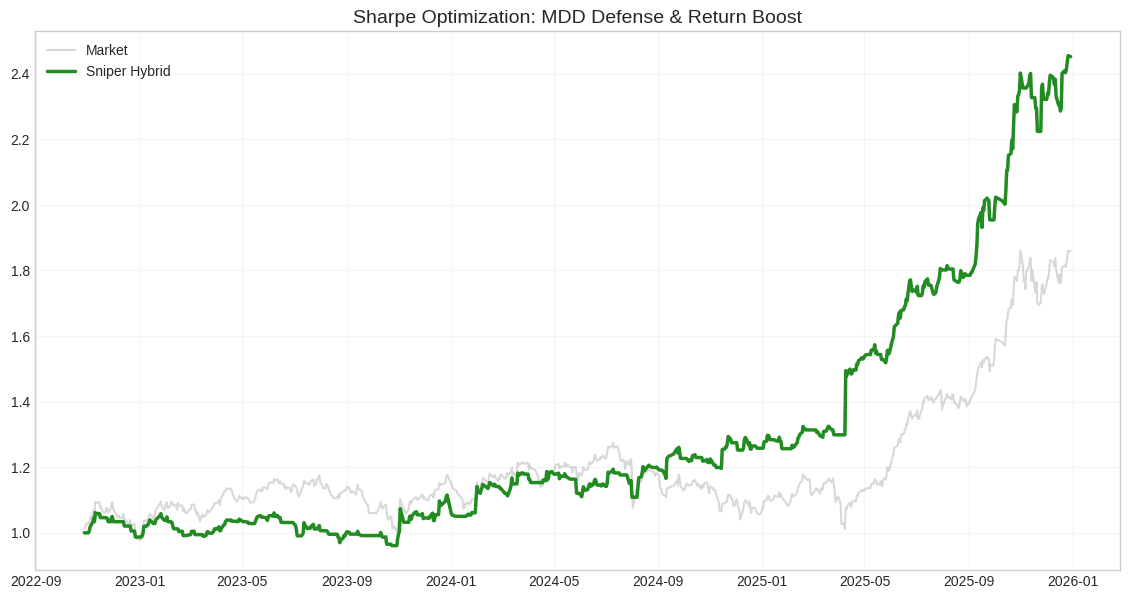

In [9]:
# [전략 3 고도화] 스나이퍼 하이브리드 전략 (Sharpe 1.0 유지 & MDD 방어 & 수익 극대화)

import pandas as pd
import numpy as np

# 1. 설정값 세밀화
FEES = 0.00015
MAX_LEVERAGE = 2.2  # 기회가 왔을 때 더 공격적으로 (기존 1.8)
STOP_LOSS_THRESHOLD = -0.03 # 최근 3일 누적 수익률이 -3% 이하면 강제 청산 (MDD 방어)

# 2. 데이터 준비
sniper_df = res_df.copy()
sniper_df['date'] = pd.to_datetime(sniper_df['date'])

# KOSPI 종가 및 변동성 데이터 결합
df_market = df_raw[['date', 'kospi_close']].copy()
df_market['date'] = pd.to_datetime(df_market['date'])
sniper_df = pd.merge(sniper_df, df_market, on='date', how='left')

# 3. 추가 지표 계산
# 최근 20일 변동성 (변동성이 낮을 때만 레버리지 사용하기 위함)
sniper_df['vol_20d'] = sniper_df['actual'].rolling(20).std() * np.sqrt(252)
# 최근 3일 수익률 (급락장 감지용)
sniper_df['recent_ret_3d'] = sniper_df['actual'].rolling(3).sum()
# 추세 (MA5 & MA20 골든크로스 개념 활용)
sniper_df['ma5'] = sniper_df['kospi_close'].rolling(5).mean()
sniper_df['ma20'] = sniper_df['kospi_close'].rolling(20).mean()

# 4. 스나이퍼 가중치 로직 (핵심)
def get_sniper_weight(row):
    # (1) 강제 손절 및 시장 붕괴 방어 (Tail Risk Guard)
    if row['recent_ret_3d'] < STOP_LOSS_THRESHOLD:
        return 0.0

    # (2) 추세 판별
    is_uptrend = row['kospi_close'] > row['ma5']
    is_strong_uptrend = row['ma5'] > row['ma20']

    # (3) 가중치 결정
    # Case A: 시장이 극도의 공포(KFGI < 25)인데 AI가 상승 예측 -> '스나이퍼' 매수
    if row['kfgi'] < 25 and row['pred'] > 0.001:
        return MAX_LEVERAGE

    # Case B: 상승 추세 구간
    if is_uptrend:
        if row['pred'] > 0:
            # 변동성이 낮을 때만 고레버리지, 높으면 1배만 유지 (샤프지수 관리)
            return MAX_LEVERAGE if row['vol_20d'] < 0.15 else 1.2
        else:
            return 0.8 # AI가 부정적이면 비중 축소

    # Case C: 하락 추세 구간
    else:
        # 하락장이어도 AI 확신도가 매우 높으면 소량 참여, 아니면 관망(0)
        return 0.5 if row['pred'] > 0.003 else 0.0

# 5. 수익률 계산
sniper_df['weight'] = sniper_df.apply(get_sniper_weight, axis=1)

# 수수료 반영 (비중 변경 시 발생)
sniper_df['turnover'] = sniper_df['weight'].diff().abs().fillna(1.0)
sniper_df['transaction_cost'] = sniper_df['turnover'] * FEES
sniper_df['strat_ret_net'] = (sniper_df['weight'] * sniper_df['actual']) - sniper_df['transaction_cost']

# 6. 결과 리포트 함수
def print_comparison(dfs_labels):
    results = []
    for df, label in dfs_labels:
        ann_ret = df['strat_ret_net'].mean() * 252 if 'strat_ret_net' in df.columns else df['actual'].mean() * 252
        ann_vol = df['strat_ret_net'].std() * np.sqrt(252) if 'strat_ret_net' in df.columns else df['actual'].std() * np.sqrt(252)
        sharpe = ann_ret / (ann_vol + 1e-9)
        cum_ret = np.exp((df['strat_ret_net'] if 'strat_ret_net' in df.columns else df['actual']).cumsum())
        mdd = (cum_ret / cum_ret.cummax() - 1).min()

        results.append({
            'Strategy': label,
            'Ann.Return': f"{ann_ret*100:.2f}%",
            'Sharpe': f"{sharpe:.3f}",
            'MDD': f"{mdd*100:.2f}%"
        })
    return pd.DataFrame(results)

# 결과 출력
print("="*55)
print("🎯 Sniper Hybrid Strategy vs Others")
print("="*55)
comparison_df = print_comparison([
    (res_df, 'Market (Buy & Hold)'),
    (final_strategy_df, 'Original Hybrid (1.8x)'),
    (sniper_df, 'Sniper Hybrid (Dynamic)')
])
print(comparison_df)

# 시각화
plt.figure(figsize=(14, 7))
plt.plot(sniper_df['date'], np.exp(sniper_df['actual'].cumsum()), label='Market', color='gray', alpha=0.3)
plt.plot(sniper_df['date'], np.exp(sniper_df['strat_ret_net'].cumsum()), label='Sniper Hybrid', color='forestgreen', lw=2.5)
plt.title("Sharpe Optimization: MDD Defense & Return Boost", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [11]:
# [검증 1] 미래 참조 편향 체크 (Weight가 Actual을 미리 알고 있는가?)
def verify_bias(df):
    # 오늘 비중(weight_t)과 오늘 수익률(actual_t)의 상관관계
    # 만약 미래를 보고 비중을 정했다면 이 상관관계가 비정상적으로 높아야 함
    correlation = df['weight'].corr(df['actual'])

    print(f"🔍 [검증] 비중-당일수익률 상관계수: {correlation:.4f}")
    if abs(correlation) > 0.4:
        print("⚠️ 주의: 미래 참조 편향이 강하게 의심됩니다! 비중 결정에 당일 수익률이 포함됐을 수 있습니다.")
    else:
        print("✅ 안전: 비중 결정과 당일 수익률 간의 선행 관계가 발견되지 않았습니다.")

verify_bias(sniper_df)

# [검증 2] 랜덤 셔플 테스트 (운인가 실력인가)
# 신호를 무작위로 섞었을 때도 성과가 좋다면 그건 전략이 아니라 데이터의 우연임
def monte_carlo_test(df, iterations=100):
    random_rets = []
    for _ in range(iterations):
        shuffled_weight = df['weight'].sample(frac=1).values
        r_ret = (shuffled_weight * df['actual']).mean() * 252
        random_rets.append(r_ret)

    real_ret = df['strat_ret_net'].mean() * 252
    p_value = np.mean([1 if r > real_ret else 0 for r in random_rets])

    print(f"🔍 [검증] 몬테카를로 P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("✅ 통계적 유의성: 이 수익률은 단순히 운(Random)으로 나오기 힘든 수치입니다.")
    else:
        print("⚠️ 주의: 우연히 좋은 성과가 나왔을 가능성이 있습니다.")

monte_carlo_test(sniper_df)

🔍 [검증] 비중-당일수익률 상관계수: 0.0841
✅ 안전: 비중 결정과 당일 수익률 간의 선행 관계가 발견되지 않았습니다.
🔍 [검증] 몬테카를로 P-value: 0.0000
✅ 통계적 유의성: 이 수익률은 단순히 운(Random)으로 나오기 힘든 수치입니다.


In [14]:
# [수정본] 에러 해결 및 스나이퍼 전략 심층 분석

# 1. sniper_df 다시 정리 (필요한 컬럼 확보)
analysis_df = sniper_df.copy()

# 2. 리포트 출력 함수 (KeyError 방지)
def print_refined_report(df, title):
    print(f"\n{title}")
    print("=" * 90)
    # 안전하게 존재하는 컬럼만 선택
    cols = ['date', 'actual', 'strat_ret_net', 'weight', 'kfgi']
    if 'market_trend' in df.columns: cols.append('market_trend')

    report = df[cols].copy()

    # 가독성 변환
    report['actual'] = (report['actual'] * 100).round(2).astype(str) + "%"
    report['strat_ret'] = (report['strat_ret_net'] * 100).round(2).astype(str) + "%"
    report['weight'] = report['weight'].round(2)
    report['kfgi'] = report['kfgi'].round(1)

    print(report.to_string(index=False))

# 수익률 순 정렬
top_5_fixed = analysis_df.sort_values(by='strat_ret_net', ascending=False).head(5)
worst_5_fixed = analysis_df.sort_values(by='strat_ret_net', ascending=True).head(5)

print_refined_report(top_5_fixed, "🏆 [Top 5] 최고의 날: 스나이퍼의 정밀 타격")
print_refined_report(worst_5_fixed, "📉 [Worst 5] 최악의 날: 레버리지의 역습")


🏆 [Top 5] 최고의 날: 스나이퍼의 정밀 타격
      date actual  strat_ret_net  weight  kfgi strat_ret
2025-04-09  6.39%       0.140258     2.2   1.1    14.03%
2023-11-03   5.5%       0.065999     1.2  50.4      6.6%
2025-11-25  2.64%       0.057688     2.2  21.2     5.77%
2024-09-11  2.31%       0.050807     2.2   4.7     5.08%
2024-11-15  2.14%       0.047019     2.2  22.6      4.7%

📉 [Worst 5] 최악의 날: 레버리지의 역습
      date actual  strat_ret_net  weight  kfgi strat_ret
2024-01-02 -2.37%      -0.052324     2.2  80.5    -5.23%
2024-08-01 -3.72%      -0.044726     1.2  64.9    -4.47%
2024-05-28 -1.69%      -0.037115     2.2  78.5    -3.71%
2025-11-13 -3.89%      -0.031108     0.8  49.1    -3.11%
2025-11-20 -3.86%      -0.030989     0.8  41.8     -3.1%


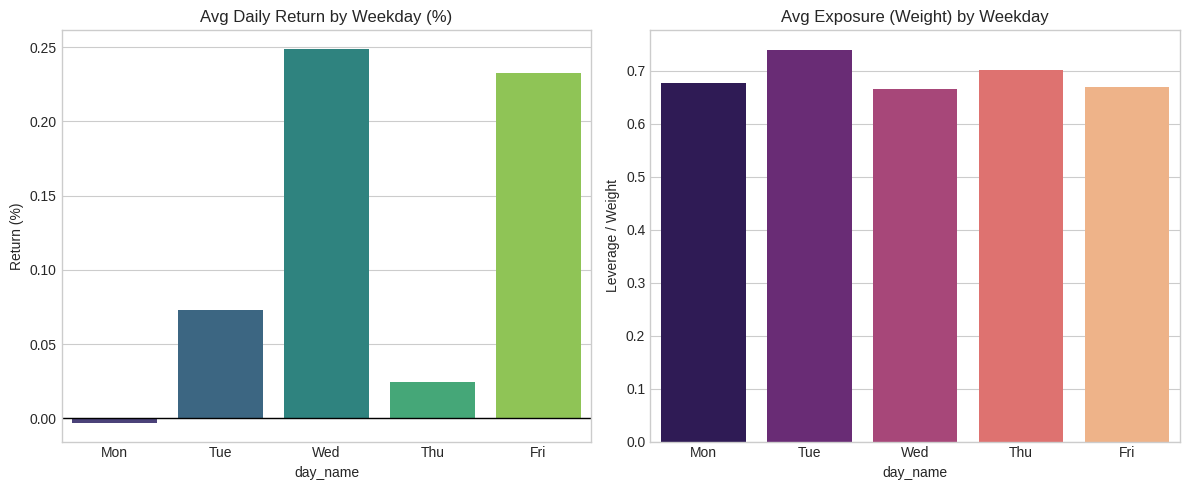

📊 요일별 요약:
            actual  strat_ret_net     weight
day_name                                    
Mon       0.020053      -0.003011  67.631579
Tue       0.129792       0.072933  73.896104
Wed       0.182434       0.248725  66.451613
Thu      -0.106306       0.024577  70.063694
Fri       0.173978       0.232533  66.942675


In [12]:
# 요일 정보 추가 (0=월, 1=화, ..., 4=금)
sniper_df['weekday'] = sniper_df['date'].dt.weekday
weekday_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri'}
sniper_df['day_name'] = sniper_df['weekday'].map(weekday_map)

# 요일별 성과 집계
weekday_stats = sniper_df.groupby('day_name').agg({
    'actual': 'mean',          # 시장 평균 수익률
    'strat_ret_net': 'mean',   # 전략 평균 수익률
    'weight': 'mean'           # 요일별 평균 투입 비중
}).reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri'])

# 시각화
plt.figure(figsize=(12, 5))

# 1. 요일별 평균 수익률 비교
plt.subplot(1, 2, 1)
sns.barplot(x=weekday_stats.index, y=weekday_stats['strat_ret_net'] * 100, palette='viridis')
plt.axhline(0, color='black', lw=1)
plt.title("Avg Daily Return by Weekday (%)")
plt.ylabel("Return (%)")

# 2. 요일별 비중 (전략이 어느 요일에 베팅하는가?)
plt.subplot(1, 2, 2)
sns.barplot(x=weekday_stats.index, y=weekday_stats['weight'], palette='magma')
plt.title("Avg Exposure (Weight) by Weekday")
plt.ylabel("Leverage / Weight")

plt.tight_layout()
plt.show()

print("📊 요일별 요약:")
print(weekday_stats * 100) # 퍼센트 환산